In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.special import factorial
from scipy.stats import poisson

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
datos_geiger = pd.read_csv('/content/drive/MyDrive/Física Experimental III/Distribuciones/Tarea1-contador-geiger/datos-geiger-19-02-2025 - Datos extraidos.csv')
datos_geiger

,particulas
0,4
1,1
2,4
3,7
4,3
...,...
139,2
140,5
141,6
142,7


In [8]:
#parametros de los datos
N = 144
lam = np.mean(datos_geiger) #Media
sig = np.std(datos_geiger) #desviacion estandar

/usr/local/lib/python3.11/dist-packages/numpy/_core/fromnumeric.py:3800: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


In [9]:
mean, var, skew, kurt = poisson.stats(lam, moments = 'mvsk')
print( f"media = {mean} , varianza= {var} ,desviacion estandar = {skew} , curtosis= {kurt}")

media = 3.2916666666666665 , varianza= 3.2916666666666665 ,desviacion estandar = 0.5511782546095504 , curtosis= 0.3037974683544304


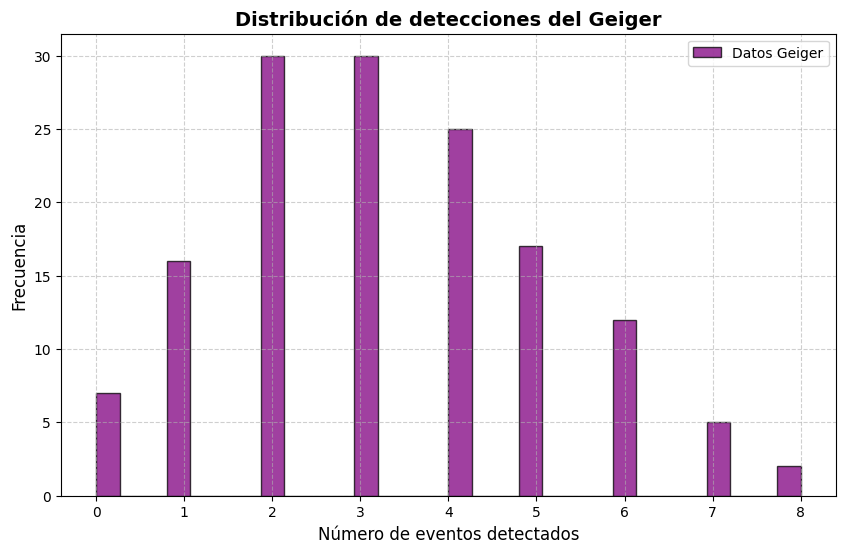

In [10]:
# Datos tomados experimentalemnte
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(datos_geiger, bins=30, color='purple', alpha=0.75, edgecolor='black', label="Datos Geiger")
ax.set_title("Distribución de detecciones del Geiger", fontsize=14, fontweight="bold")
ax.set_xlabel("Número de eventos detectados", fontsize=12)
ax.set_ylabel("Frecuencia", fontsize=12)
ax.legend()
ax.grid(True, linestyle="--", alpha=0.6)
plt.show()

1. Haciendo un análisis preliminar de los datos, determine si encuentra datos atípicos, para esto haga un ``boxplot`` y remueva aquellos que no cumplan con el criterio de los cuartiles.

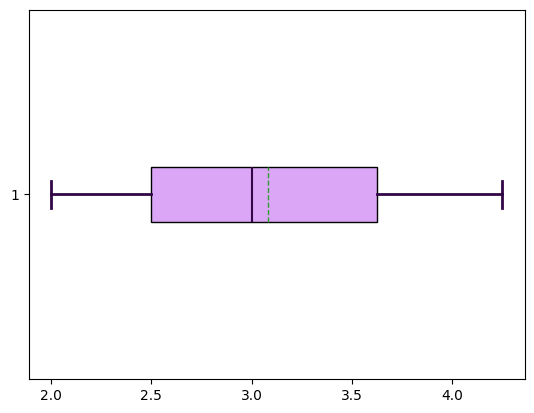

In [11]:
#Cuartiles
cuartiles = np.quantile(datos_geiger, [0.25, 0.5, 0.75])
#Diagrama boxplot (cajas y bigotes - numeral 1)
fig, ax = plt.subplots()
ax.boxplot(cuartiles, vert = False, showmeans = True, meanline = True,
           medianprops = dict(color = "#320647", linewidth = 1.5),  #Color y grosor linea media
           flierprops = dict(marker = "s", markerfacecolor = "purple"), #Marcar datos dispersos
           patch_artist = True,
           boxprops = dict(facecolor = "#dca6f7"), #fondo de la caja
           whiskerprops = dict(color = "#320647", linewidth = 2), capprops = dict(color = "#320647", linewidth = 2)) #Color bigotes y verticales de bigotes

fig.show()

2.Obtenga el valor medio λ y la desviación estándar de los datos. Luego, usando dicho λ cree un conjunto de datos simulados que sigan una distribución de Poisson (ayuda: se recomienda usar ``scipy.stats.poisson.rmv``).

In [12]:
vm_lam = float(datos_geiger.sum()/datos_geiger.count())  #valor medio de lamda
desv_est = np.sqrt(vm_lam)
print(f'El valor medio λ es {vm_lam} y la desviación estándar es {desv_est}')

#conjunto de datos simulados
datos_simulados = np.random.poisson(vm_lam, 144) #la misma cantidad de datos que tenemos

El valor medio λ es 3.2916666666666665 y la desviación estándar es 1.8142950880897701


<ipython-input-12-0a9a227231ae>:1: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  vm_lam = float(datos_geiger.sum()/datos_geiger.count())  #valor medio de lamda


In [13]:
mean, var, skew, kurt = poisson.stats(vm_lam, moments = 'mvsk')
print( f"media = {mean} , varianza= {var} ,desviacion estandar = {skew} , curtosis= {kurt}")

media = 3.2916666666666665 , varianza= 3.2916666666666665 ,desviacion estandar = 0.5511782546095504 , curtosis= 0.3037974683544304


3. Grafique los datos reales y los datos simulados conjuntamente. ¿Qué diferencias o similitudes encuentra entre los datos experimentales y simulados?

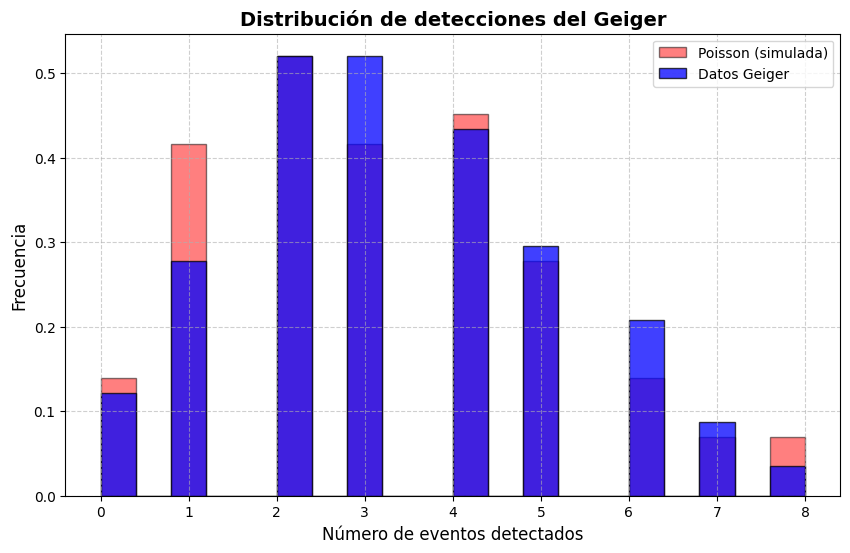

In [24]:
fig, ax = plt.subplots(figsize=(10, 6))

# Histograma con etiquetas y mejoras
ax.hist(datos_simulados , bins=20, color='red', alpha=0.5, edgecolor='black', label="Poisson (simulada)", density=True)
ax.hist(datos_geiger, bins=20, color='blue', alpha=0.75, edgecolor='black', label="Datos Geiger", density=True)

ax.set_title("Distribución de detecciones del Geiger", fontsize=14, fontweight="bold")
ax.set_xlabel("Número de eventos detectados", fontsize=12)
ax.set_ylabel("Frecuencia", fontsize=12)
ax.legend()
ax.grid(True, linestyle="--", alpha=0.6)

# Mostrar la gráfica
plt.show()


Los datos simulados tienen una desviacion estandar mayor a la de los datos tomados experimentalmente en clase.

4. Realice un gráfico de los residuos de ambos conjuntos de datos y grafique conjuntamente, ¿puede decir que los datos están distribuidos aleatoriamente?.

In [15]:
df_datossimulados = pd.DataFrame({'Valor': pd.Series(datos_simulados).value_counts().index,
                               'Frecuencia': pd.Series(datos_simulados).value_counts().values})
df_datossimulados

,Valor,Frecuencia
0,2,30
1,4,26
2,1,24
3,3,24
4,5,16
5,6,8
6,0,8
7,7,4
8,8,4


In [16]:
datos_geiger1 =  pd.DataFrame({'Valor': pd.Series(datos_geiger["particulas"]).value_counts().index,
                               'Frecuencia': pd.Series(datos_geiger["particulas"]).value_counts().values})
datos_geiger1

,Valor,Frecuencia
0,3,30
1,2,30
2,4,25
3,5,17
4,1,16
5,6,12
6,0,7
7,7,5
8,8,2


In [17]:
Residuos = []
Valorr = []
for i in range(0, len(datos_geiger1)):
  for k in range(0, len(df_datossimulados)):
    if datos_geiger1["Valor"][i] == df_datossimulados["Valor"][k]:
      Residuos.append( datos_geiger1["Frecuencia"][i] - df_datossimulados["Frecuencia"][k])
      Valorr.append(datos_geiger1["Valor"][i])

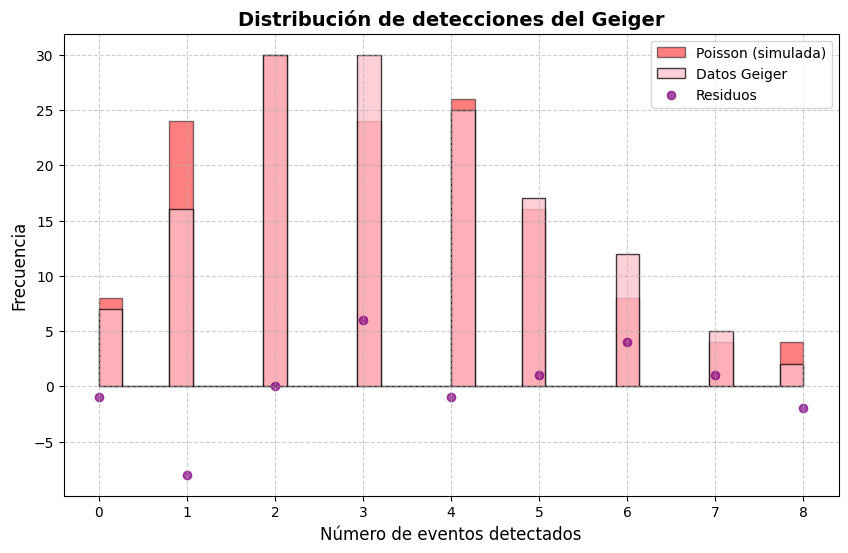

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(datos_simulados , bins=30, color='red', alpha=0.5, edgecolor='black', label="Poisson (simulada)")
ax.hist(datos_geiger, bins=30, color='pink', alpha=0.75, edgecolor='black', label="Datos Geiger")
ax.scatter(Valorr, Residuos, color="purple", alpha=0.7 , label = "Residuos")

ax.set_title("Distribución de detecciones del Geiger", fontsize=14, fontweight="bold")
ax.set_xlabel("Número de eventos detectados", fontsize=12)
ax.set_ylabel("Frecuencia", fontsize=12)
ax.legend()
ax.grid(True, linestyle="--", alpha=0.6)
plt.show()


Dado que observamos que los residuos no tienen una forma determinada, estando dispersos aleatoriamente, podemos decir que efectivament, los datos estan distribuidos de forma aleatoria.

5. Graficar los histogramas de cada conjunto de datos y superponga la distribución teórica. Analizar y concluir sobre los resultados obtenidos.

In [19]:
def poisson(media, x):
  y = ((media ** x ) * np.exp(-media)) / factorial(x)
  return y

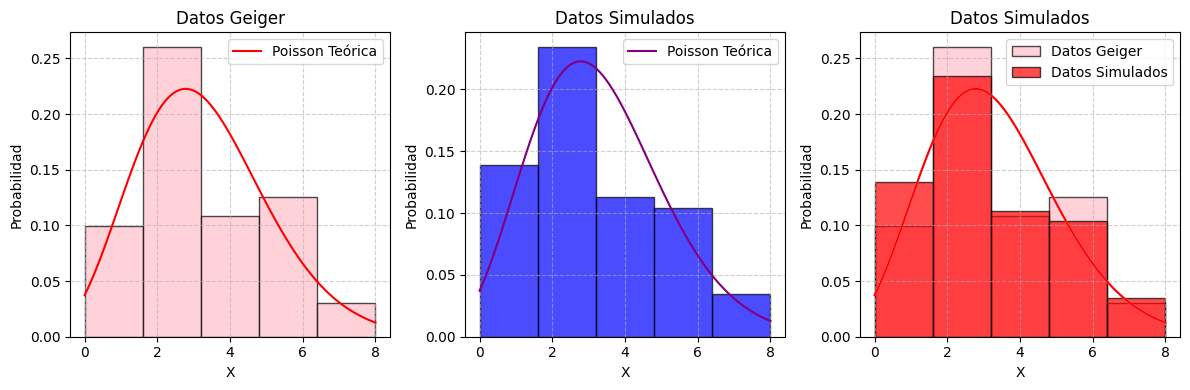

In [20]:
t = np.linspace(0, 8, 100)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
# 1 Histograma de datos geiger
axes[0].hist(datos_geiger , bins=5, color="pink", edgecolor="black", alpha=0.7 , density = True)
axes[0].plot(t, poisson(lam,t), color="red", label="Poisson Teórica")
axes[0].set_title("Datos Geiger")
axes[0].set_xlabel("X")
axes[0].set_ylabel("Probabilidad")
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.6)

#2 histograma datos simulados
axes[1].hist(datos_simulados , bins=5, color="blue", edgecolor="black", alpha=0.7 , density = True)
axes[1].plot(t, poisson(float(vm_lam), t), color="purple", label="Poisson Teórica")
axes[1].set_title("Datos Simulados")
axes[1].set_xlabel("X")
axes[1].set_ylabel("Probabilidad")
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.6)

#3 superposicion de ambas
axes[2].hist(datos_geiger , bins=5, color="pink", edgecolor="black", alpha=0.7 , density = True , label = "Datos Geiger")
axes[2].plot(t, poisson(lam,t), color="pink")
axes[2].hist(datos_simulados , bins=5, color="red", edgecolor="black", alpha=0.7 , density = True, label = "Datos Simulados")
axes[2].plot(t, poisson(float(vm_lam), t), color="red")
axes[2].set_title("Datos Simulados")
axes[2].set_xlabel("X")
axes[2].set_ylabel("Probabilidad")
axes[2].legend()
axes[2].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


La distribucion teorica se ajusta casi perfectamente a la disribucion de los datos tomados experimentalmente y a la distribucion de los datos simulados. El resultado implica que se realizo un buen modelo del problema fisico.

6. Calcule la probabilidad para los datos experimentales y simulados de que se detecten entre 2 a 5 partículas en 10 s. ¿Cuántos eventos esperaría ver en 3 minutos?

In [25]:
# @title .
Pe , Ps = 0 , 0   #Con la definicion teorica
for i in range(2,6):
  Pe += poisson(lam,i)
  Ps += poisson(float(vm_lam),i)
print(f'La probabilidad de que se detecten entre 2 a 5 partículas en 10s, con los datos experimentales es {Pe}, \nLa probabilidad de que se detecten entre 2 a 5 partículas en 10s, con los datos simulados es {Ps}')


La probabilidad de que se detecten entre 2 a 5 partículas en 10s, con los datos experimentales es 0.7242621893490389, 
La probabilidad de que se detecten entre 2 a 5 partículas en 10s, con los datos simulados es 0.7242621893490389


In [26]:
# @title .
#Con la lista de Datos
Pe , Ps = 0 , 0 #Pe:  Probabilidad de datos Experimentales  , Ps: Probabilidad de datos Simulados
for i in range(0, len(datos_geiger1)):
  if datos_geiger1["Valor"][i] >= 2 and datos_geiger1["Valor"][i] <= 5:
    Pe += datos_geiger1["Frecuencia"][i]/144

for i in range(0, len(df_datossimulados)):
  if df_datossimulados["Valor"][i] >= 2 and df_datossimulados["Valor"][i] <= 5:
    Ps += df_datossimulados["Frecuencia"][i]/144

print(f'La probabilidad de que se detecten entre 2 a 5 partículas en 10s, con los datos experimentales es {Pe}, \nLa probabilidad de que se detecten entre 2 a 5 partículas en 10s, con los datos simulados es {Ps}')


La probabilidad de que se detecten entre 2 a 5 partículas en 10s, con los datos experimentales es 0.7083333333333334, 
La probabilidad de que se detecten entre 2 a 5 partículas en 10s, con los datos simulados es 0.6666666666666667


In [23]:
# @title .
#En un lapso de 3minutos se modifica lamda
lam_3min = lam*180/10
vm_lam_3min = float(vm_lam)*180/10
print(f'En 3 minutos se esperan {lam_3min} eventos con los datos experimentales y {vm_lam_3min} eventos con los datos simulados')

En 3 minutos se esperan 59.25 eventos con los datos experimentales y 59.25 eventos con los datos simulados
